In [ ]:
!pip install -q pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 1.2 MB/s eta 0:00:00


In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

def apply_constant_oracle(qc, n, value=1):
    if value == 1:
        qc.x(n)

def run_deutsch_jozsa_constant(n=3, value=1):
    qc = QuantumCircuit(n + 1, n)
    qc.x(n)
    qc.h(range(n + 1))
    qc.barrier()

    apply_constant_oracle(qc, n, value=value)
    qc.barrier()

    qc.h(range(n))
    qc.measure(range(n), range(n))

    simulator = AerSimulator()
    counts = simulator.run(qc, shots=1024).result().get_counts()
    return qc, counts

n = 3
qc_easy, counts_easy = run_deutsch_jozsa_constant(n=n, value=1)
print("Exercise 1 (Easy) Counts:", counts_easy)
print("Classification:", "Constant" if '0'*n in counts_easy else "Balanced")
print("\nCircuit Diagram:")
print(qc_easy.draw('text'))

Exercise 1 (Easy) Counts: {'000': 1024}
Classification: Constant

Circuit Diagram:
     ┌───┐      ░       ░ ┌───┐┌─┐      
q_0: ┤ H ├──────░───────░─┤ H ├┤M├──────
     ├───┤      ░       ░ ├───┤└╥┘┌─┐   
q_1: ┤ H ├──────░───────░─┤ H ├─╫─┤M├───
     ├───┤      ░       ░ ├───┤ ║ └╥┘┌─┐
q_2: ┤ H ├──────░───────░─┤ H ├─╫──╫─┤M├
     ├───┤┌───┐ ░ ┌───┐ ░ └───┘ ║  ║ └╥┘
q_3: ┤ X ├┤ H ├─░─┤ X ├─░───────╫──╫──╫─
     └───┘└───┘ ░ └───┘ ░       ║  ║  ║ 
c: 3/═══════════════════════════╩══╩══╩═
                                0  1  2 


In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

def apply_parity_oracle(qc, n):
    for qubit in range(n):
        qc.cx(qubit, n)

def run_deutsch_jozsa_parity(n=3):
    qc = QuantumCircuit(n + 1, n)
    qc.x(n)
    qc.h(range(n + 1))
    qc.barrier()

    apply_parity_oracle(qc, n)
    qc.barrier()

    qc.h(range(n))
    qc.measure(range(n), range(n))

    simulator = AerSimulator()
    counts = simulator.run(qc, shots=1024).result().get_counts()
    return qc, counts

n = 3
qc_med, counts_med = run_deutsch_jozsa_parity(n=n)
print("Exercise 2 (Medium) Counts:", counts_med)
print("Classification:", "Constant" if '0'*n in counts_med and len(counts_med) == 1 else "Balanced")
print("\nCircuit Diagram:")
print(qc_med.draw('text'))

Exercise 2 (Medium) Counts: {'111': 1024}
Classification: Balanced

Circuit Diagram:
     ┌───┐      ░                 ░ ┌───┐┌─┐      
q_0: ┤ H ├──────░───■─────────────░─┤ H ├┤M├──────
     ├───┤      ░   │             ░ ├───┤└╥┘┌─┐   
q_1: ┤ H ├──────░───┼────■────────░─┤ H ├─╫─┤M├───
     ├───┤      ░   │    │        ░ ├───┤ ║ └╥┘┌─┐
q_2: ┤ H ├──────░───┼────┼────■───░─┤ H ├─╫──╫─┤M├
     ├───┤┌───┐ ░ ┌─┴─┐┌─┴─┐┌─┴─┐ ░ └───┘ ║  ║ └╥┘
q_3: ┤ X ├┤ H ├─░─┤ X ├┤ X ├┤ X ├─░───────╫──╫──╫─
     └───┘└───┘ ░ └───┘└───┘└───┘ ░       ║  ║  ║ 
c: 3/═════════════════════════════════════╩══╩══╩═
                                          0  1  2 


In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

def run_general_dj(n, oracle_type='balanced'):
    qc = QuantumCircuit(n + 1, n)
    qc.x(n)
    qc.h(range(n + 1))
    qc.barrier()

    if oracle_type == 'constant':
        qc.x(n)
    elif oracle_type == 'balanced':
        for qubit in range(n):
            qc.cx(qubit, n)
    else:
        raise ValueError("Must be 'constant' or 'balanced'")

    qc.barrier()
    qc.h(range(n))
    qc.measure(range(n), range(n))

    simulator = AerSimulator()
    counts = simulator.run(qc, shots=1024).result().get_counts()
    return counts

print(f"{'n':<4} | {'Oracle Type':<12} | {'Measured Bitstring':<20} | {'Classification':<12}")
print("-" * 55)

for n_val in range(2, 6):
    for o_type in ['constant', 'balanced']:
        counts = run_general_dj(n_val, oracle_type=o_type)
        measured = list(counts.keys())[0]
        classification = "Constant" if measured == '0' * n_val else "Balanced"
        print(f"{n_val:<4} | {o_type:<12} | {measured:<20} | {classification:<12}")

n    | Oracle Type  | Measured Bitstring   | Classification
-------------------------------------------------------
2    | constant     | 00                   | Constant    
2    | balanced     | 11                   | Balanced    
3    | constant     | 000                  | Constant    
3    | balanced     | 111                  | Balanced    
4    | constant     | 0000                 | Constant    
4    | balanced     | 1111                 | Balanced    
5    | constant     | 00000                | Constant    
5    | balanced     | 11111                | Balanced    


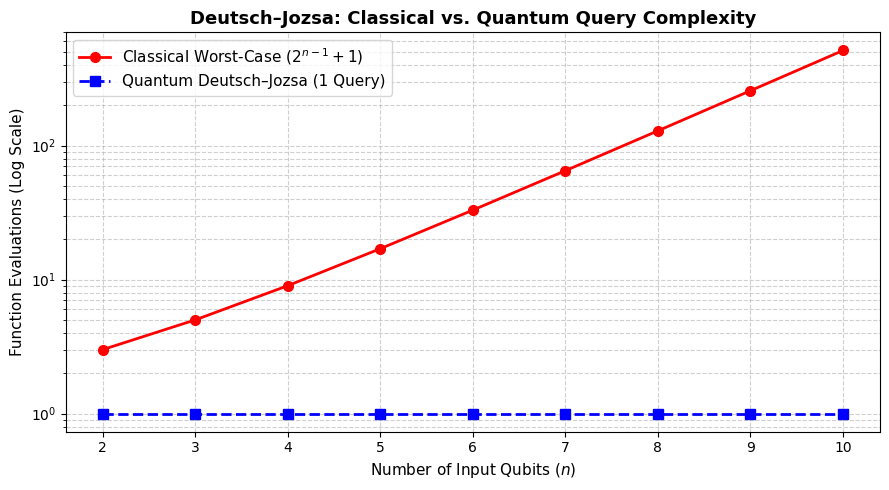

n    | Classical Worst-Case   | Quantum  | Speedup Factor 
-------------------------------------------------------
2    | 3                      | 1        | 3.0            x
3    | 5                      | 1        | 5.0            x
4    | 9                      | 1        | 9.0            x
5    | 17                     | 1        | 17.0           x
6    | 33                     | 1        | 33.0           x
7    | 65                     | 1        | 65.0           x
8    | 129                    | 1        | 129.0          x
9    | 257                    | 1        | 257.0          x
10   | 513                    | 1        | 513.0          x


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

n_vals = np.arange(2, 11)
classical_worst = 2**(n_vals - 1) + 1
quantum_queries = np.ones_like(n_vals)

plt.figure(figsize=(9, 5))
plt.plot(n_vals, classical_worst, 'ro-', linewidth=2, markersize=7, label=r'Classical Worst-Case ($2^{n-1} + 1$)')
plt.plot(n_vals, quantum_queries, 'bs--', linewidth=2, markersize=7, label='Quantum Deutsch–Jozsa (1 Query)')

plt.yscale('log')
plt.title("Deutsch–Jozsa: Classical vs. Quantum Query Complexity", fontsize=13, fontweight='bold')
plt.xlabel("Number of Input Qubits ($n$)", fontsize=11)
plt.ylabel("Function Evaluations (Log Scale)", fontsize=11)
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"{'n':<4} | {'Classical Worst-Case':<22} | {'Quantum':<8} | {'Speedup Factor':<15}")
print("-" * 55)
for n, c, q in zip(n_vals, classical_worst, quantum_queries):
    print(f"{n:<4} | {c:<22} | {q:<8} | {c/q:<15.1f}x")

In [ ]:
import random

def run_random_balanced_dj(n):
    qc = QuantumCircuit(n + 1, n)

    # 1. Target |1>
    qc.x(n)

    # 2. Superposition
    qc.h(range(n + 1))
    qc.barrier()

    # 3. Random balanced oracle construction
    mask = [random.choice([0, 1]) for _ in range(n)]

    # Apply X-gates according to mask
    for i in range(n):
        if mask[i] == 1:
            qc.x(i)

    # Apply CNOTs
    for i in range(n):
        qc.cx(i, n)

    # Uncompute mask
    for i in range(n):
        if mask[i] == 1:
            qc.x(i)

    qc.barrier()

    # 4. Hadamard on inputs
    qc.h(range(n))

    # 5. Measure inputs
    qc.measure(range(n), range(n))

    # Simulate
    simulator = AerSimulator()
    counts = simulator.run(qc, shots=1024).result().get_counts()
    return mask, counts

print("Testing Randomized Balanced Oracles:")
print(f"{'Trial':<6} | {'Mask Applied':<16} | {'Measured State':<16} | {'Result':<10}")
print("-" * 55)

n = 4
for trial in range(1, 6):
    mask, counts = run_random_balanced_dj(n)
    measured = list(counts.keys())[0]
    is_balanced = (measured != '0' * n)
    print(f"{trial:<6} | {str(mask):<16} | {measured:<16} | {'Balanced' if is_balanced else 'Constant'}")

Testing Randomized Balanced Oracles:
Trial  | Mask Applied     | Measured State   | Result    
-------------------------------------------------------
1      | [1, 1, 1, 0]     | 1111             | Balanced
2      | [0, 0, 0, 0]     | 1111             | Balanced
3      | [1, 1, 0, 0]     | 1111             | Balanced
4      | [0, 0, 0, 0]     | 1111             | Balanced
5      | [0, 0, 0, 1]     | 1111             | Balanced
